In [ ]:
import pandas
names = ['Alcohol', 'Flavanoids','wineClass']
dataset = pandas.read_csv('wine-s.csv', header=0, names=names)
x = dataset.iloc[:, 0:2].values
y = dataset.iloc[:, 2].values

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(0)
perm = np.random.permutation(178)
x = dataset.iloc[:,0:2].values
y = dataset.iloc[:,2].values
trainx = dataset.iloc[perm[0:130],0:2].values
trainy = dataset.iloc[perm[0:130],2].values
testx = dataset.iloc[perm[130:178], 0:2].values
testy = dataset.iloc[perm[130:178],2].values

In [ ]:
print(trainx.shape)
print(trainy.shape)
print(testx.shape)
print(testy.shape)

(130, 2)
(130,)
(48, 2)
(48,)


In [ ]:
sum(trainy==1), sum(trainy==2), sum(trainy==3)

(np.int64(43), np.int64(54), np.int64(33))

In [ ]:
sum(testy==1), sum(testy==2), sum(testy==3)

(np.int64(16), np.int64(17), np.int64(15))

Text(0, 0.5, 'Density')

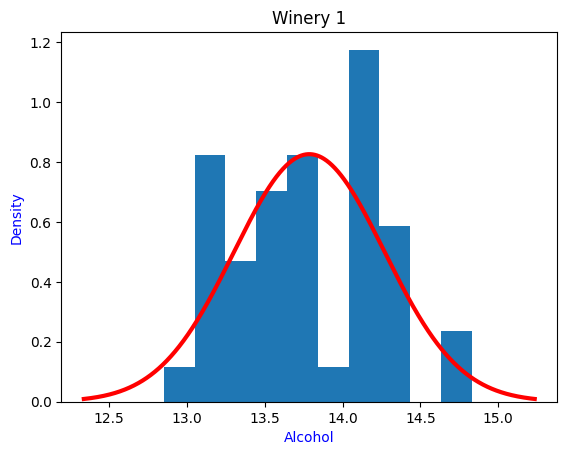

In [ ]:
from scipy.stats import norm, multivariate_normal
feature=0
label=1
plt.hist(trainx[trainy==label,feature], density=True)
mu = np.mean(trainx[trainy==label,feature]) # mean
var = np.var(trainx[trainy==label,feature]) # variance
std = np.sqrt(var) # standard deviation
x_axis = np.linspace(mu - 3*std, mu + 3*std, 1000)
plt.plot(x_axis, norm.pdf(x_axis,mu,std), 'r', lw=3)
plt.title("Winery "+str(label) )
plt.xlabel(names[feature], color='blue')
plt.ylabel('Density', color='blue')

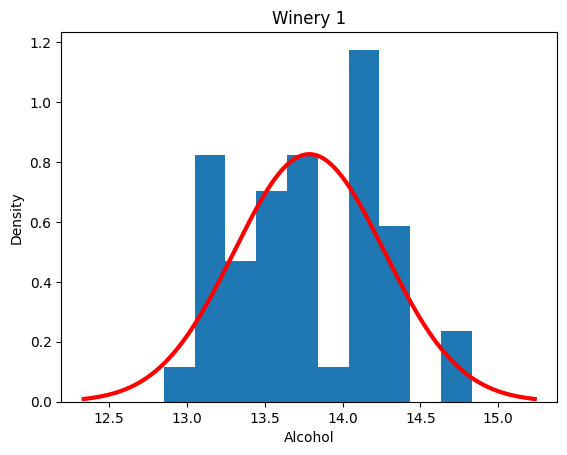

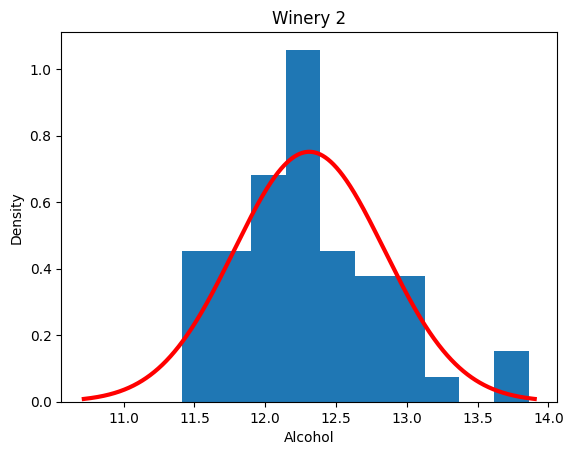

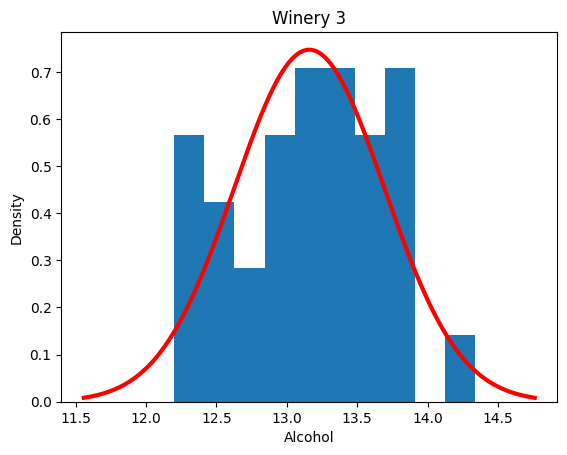

In [ ]:
feature = 0

for label in [1, 2, 3]:
    plt.figure()
    plt.hist(trainx[trainy==label,feature], density=True)

    mu = np.mean(trainx[trainy==label,feature])
    var = np.var(trainx[trainy==label,feature])
    std = np.sqrt(var)

    x_axis = np.linspace(mu - 3*std, mu + 3*std, 1000)
    plt.plot(x_axis, norm.pdf(x_axis,mu,std), 'r', lw=3)

    plt.title("Winery " + str(label))
    plt.xlabel(names[feature])
    plt.ylabel('Density')

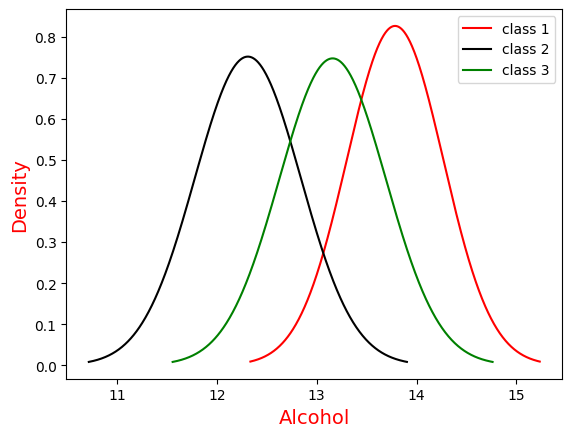

In [ ]:
def fit_generative_model(x,y,feature):
 k = 3 # number of classes
 mu = np.zeros(k+1) # list of means
 var = np.zeros(k+1) # list of variances
 pi = np.zeros(k+1) # list of class weights
 for label in range(1,k+1):
  indices = (y==label)
  mu[label] = np.mean(x[indices,feature])
  var[label] = np.var(x[indices,feature])
  pi[label] = float(sum(indices))/float(len(y))
 return mu, var, pi
feature=0
mu, var, pi = fit_generative_model(trainx, trainy, feature)
colors = ['r', 'k', 'g']
for label in range(1,4):
 m = mu[label]
 s = np.sqrt(var[label])
 x_axis = np.linspace(m - 3*s, m+3*s, 1000)
 plt.plot(x_axis, norm.pdf(x_axis,m,s), colors[label-1], label="class " + str(label))
plt.xlabel(names[feature], fontsize=14, color='red')
plt.ylabel('Density', fontsize=14, color='red')
plt.legend()
plt.show()

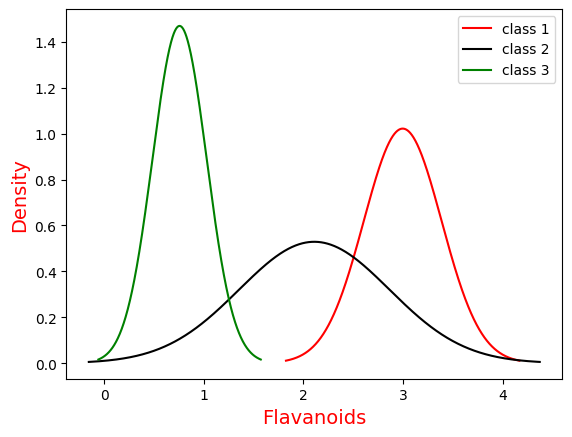

In [ ]:
feature = 1  # Flavanoids

mu, var, pi = fit_generative_model(trainx, trainy, feature)

colors = ['r', 'k', 'g']

for label in range(1,4):
    m = mu[label]
    s = np.sqrt(var[label])
    x_axis = np.linspace(m - 3*s, m+3*s, 1000)
    plt.plot(x_axis, norm.pdf(x_axis, m, s), colors[label-1], label="class " + str(label))

plt.xlabel("Flavanoids", fontsize=14, color='red')
plt.ylabel('Density', fontsize=14, color='red')
plt.legend()
plt.show()

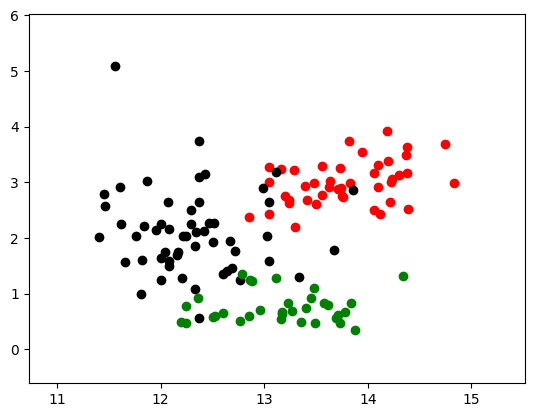

In [ ]:
def find_range(x):
 lower = min(x)
 upper = max(x)
 width = upper - lower
 lower = lower - 0.2 * width
 upper = upper + 0.2 * width
 return lower, upper
f1=0
f2=1
x1_lower, x1_upper = find_range(trainx[:,f1])
x2_lower, x2_upper = find_range(trainx[:,f2])
plt.xlim(x1_lower, x1_upper) # limit along x1-axis
plt.ylim(x2_lower, x2_upper) # limit along x2-axis
colors = ['r', 'k', 'g']
for label in range(1,4):
 plt.plot(trainx[trainy==label,f1], trainx[trainy==label,f2], marker='o', ls='None',
c=colors[label-1])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kNN1 = KNeighborsClassifier(n_neighbors=1)
kNN1.fit(trainx, trainy)

KNeighborsClassifier(n_neighbors=1)

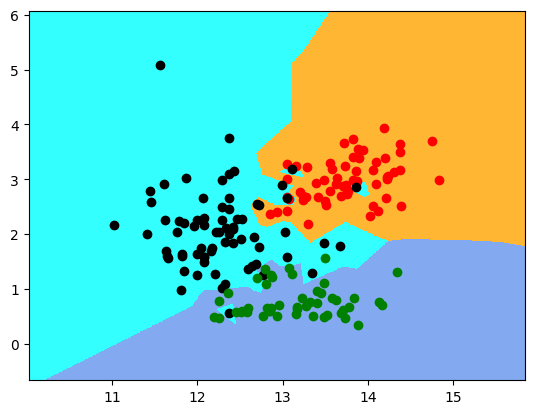

In [ ]:
x = dataset.iloc[:,0:2].values
y = dataset.iloc[:,2].values
from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ['darkorange', 'c', 'darkblue']
h=0.01
x_min, x_max = x[:, 0].min() - 1,x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
 np.arange(y_min, y_max, h))
Z = kNN1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=.8, shading='auto')
for label in range(1,4):
 plt.plot(x[y==label,f1], x[y==label,f2], marker='o', ls='None', c=colors[label-1])

In [ ]:
predictions = kNN1.predict(testx)
from sklearn import metrics
print(metrics.confusion_matrix(testy, predictions))

[[14  2  0]
 [ 2 15  0]
 [ 0  2 13]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 10]

models = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(trainx, trainy)
    models.append(model)

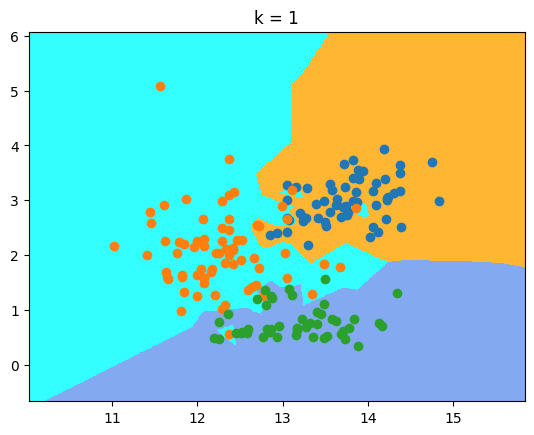

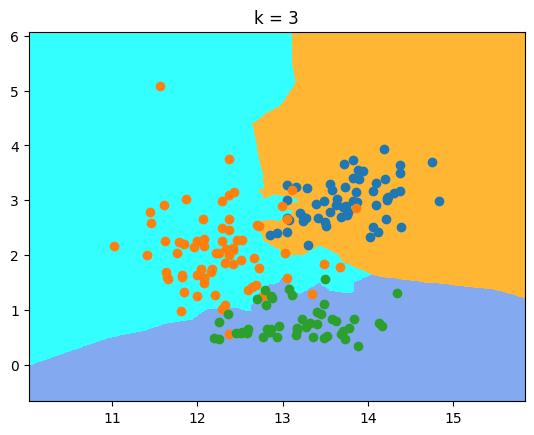

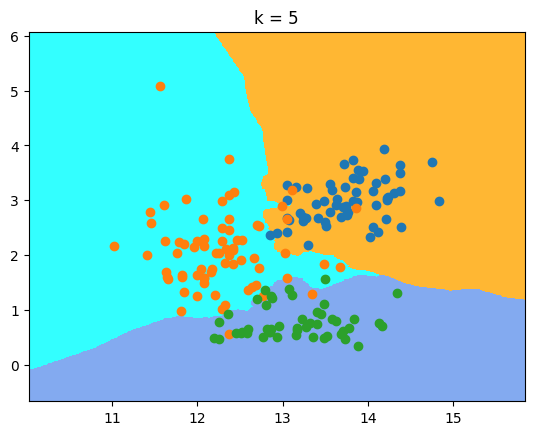

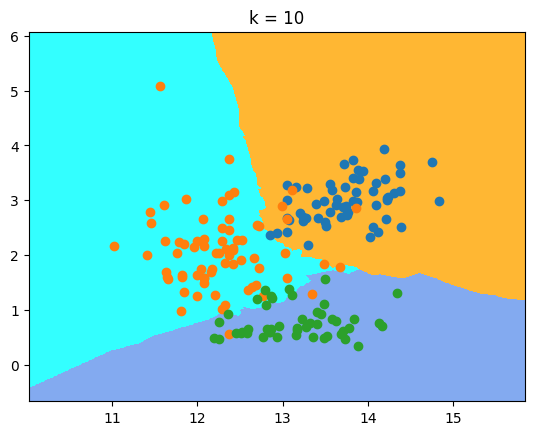

In [ ]:
for i, k in enumerate(k_values):
    model = models[i]

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=.8, shading='auto')

    for label in range(1,4):
        plt.plot(x[y==label,0], x[y==label,1], marker='o', ls='None')

    plt.title("k = " + str(k))
    plt.show()

In [ ]:
from sklearn import metrics

for k in [1,3,5,10]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(trainx, trainy)

    pred = model.predict(testx)
    print("k =", k)
    print(metrics.confusion_matrix(testy, pred))

k = 1
[[14  2  0]
 [ 2 15  0]
 [ 0  2 13]]
k = 3
[[16  0  0]
 [ 1 15  1]
 [ 0  1 14]]
k = 5
[[16  0  0]
 [ 0 17  0]
 [ 0  1 14]]
k = 10
[[16  0  0]
 [ 0 17  0]
 [ 0  2 13]]
